In [1]:
import numpy as np
import pandas as pd

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import statsmodels.formula.api as smf

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('churn.csv')

## Datanın təmizlənməsi - Data Cleaning

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         45211 non-null  int64 
 1   age        45211 non-null  int64 
 2   job        45211 non-null  object
 3   marital    45211 non-null  object
 4   education  45211 non-null  object
 5   default    45211 non-null  object
 6   balance    45211 non-null  int64 
 7   housing    45211 non-null  object
 8   loan       45211 non-null  object
 9   contact    45211 non-null  object
 10  day        45211 non-null  int64 
 11  month      45211 non-null  object
 12  duration   45211 non-null  int64 
 13  campaign   45211 non-null  int64 
 14  pdays      45211 non-null  int64 
 15  previous   45211 non-null  int64 
 16  poutcome   45211 non-null  object
 17  y          45211 non-null  object
dtypes: int64(8), object(10)
memory usage: 6.2+ MB


In [3]:
data["y"].unique()

array(['no', 'yes'], dtype=object)

In [3]:
data["y"] = data["y"].replace({"yes": 1, "no": 0}).astype("category")

C:\Users\tarlan.cabiyev\AppData\Local\Temp\ipykernel_14344\1380780874.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["y"] = data["y"].replace({"yes": 1, "no": 0}).astype("category")


In [4]:
data["y"].value_counts(normalize=True).round(2)

y
0    0.88
1    0.12
Name: proportion, dtype: float64

In [5]:
na_df = data.isna().sum().reset_index().rename(columns={'index': 'col_name', 0: 'na_count'})
na_df = na_df.sort_values('na_count', ascending=False).reset_index(drop=True)
na_df['pcnt'] = (na_df['na_count'] / len(data)) * 100
na_df

,col_name,na_count,pcnt
0,id,0,0.0
1,age,0,0.0
2,poutcome,0,0.0
3,previous,0,0.0
4,pdays,0,0.0
5,campaign,0,0.0
6,duration,0,0.0
7,month,0,0.0
8,day,0,0.0
9,contact,0,0.0


In [6]:
variables = na_df.loc[na_df['pcnt'] < 60, 'col_name'].tolist()
data = data[variables].drop(columns=['id'], errors='ignore')

In [7]:
target = "y"

In [8]:
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
df_num = data[num_cols]
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       45211 non-null  int64
 1   previous  45211 non-null  int64
 2   pdays     45211 non-null  int64
 3   campaign  45211 non-null  int64
 4   duration  45211 non-null  int64
 5   day       45211 non-null  int64
 6   balance   45211 non-null  int64
dtypes: int64(7)
memory usage: 2.4 MB


In [9]:
chr_cols = data.select_dtypes(include=['object']).columns.tolist()
df_chr = data[chr_cols]
df_chr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   poutcome   45211 non-null  object
 1   month      45211 non-null  object
 2   contact    45211 non-null  object
 3   loan       45211 non-null  object
 4   housing    45211 non-null  object
 5   default    45211 non-null  object
 6   education  45211 non-null  object
 7   marital    45211 non-null  object
 8   job        45211 non-null  object
dtypes: object(9)
memory usage: 3.1+ MB


### Numeric dəyişənlərin təmizlənməsi

In [10]:
df_num.isna().sum()

age         0
previous    0
pdays       0
campaign    0
duration    0
day         0
balance     0
dtype: int64

In [11]:
med_imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=200, random_state=123, n_jobs=-1),
    random_state=123,
    max_iter=10,
    initial_strategy='median',
    skip_complete=True
)

df_num = pd.DataFrame(
    med_imputer.fit_transform(df_num),
    columns=df_num.columns
)

df_num.isna().sum()

age         0
previous    0
pdays       0
campaign    0
duration    0
day         0
balance     0
dtype: int64

### Character dəyişənlərin təmizlənməsi

In [12]:
df_chr.isna().sum()

poutcome     0
month        0
contact      0
loan         0
housing      0
default      0
education    0
marital      0
job          0
dtype: int64

In [13]:
mode_imputer = SimpleImputer(strategy='most_frequent')

df_chr = pd.DataFrame(
    mode_imputer.fit_transform(df_chr),
    columns=df_chr.columns
)

df_chr.isna().sum()

poutcome     0
month        0
contact      0
loan         0
housing      0
default      0
education    0
marital      0
job          0
dtype: int64

## Kəmiyyət dəyişənlərdə Outlier'ların həll olunması

In [14]:
num_vars = df_num.columns
num_vars

Index(['age', 'previous', 'pdays', 'campaign', 'duration', 'day', 'balance'], dtype='object')

In [15]:
for var in num_vars:
    q1 = df_num[var].quantile(0.25)
    q3 = df_num[var].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df_num[var][(df_num[var] < lower_bound) | (df_num[var] > upper_bound)]
    if not outliers.empty:
        print(f'Outliers in {var}: {outliers.values[:5]} ...')
        print('')

Outliers in age: [83. 75. 75. 83. 75.] ...

Outliers in previous: [3. 1. 4. 4. 3.] ...

Outliers in pdays: [151. 166.  91.  86. 143.] ...

Outliers in campaign: [7. 8. 7. 8. 7.] ...

Outliers in duration: [1666. 1492.  787. 1778.  812.] ...

Outliers in balance: [10635.  6530. 12223.  5935.  4384.] ...



In [16]:
for var in num_vars:
    q1 = df_num[var].quantile(0.25)
    q3 = df_num[var].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df_num.loc[df_num[var] < lower_bound, var] = lower_bound
    df_num.loc[df_num[var] > upper_bound, var] = upper_bound

In [17]:
for var in num_vars:
    q1 = df_num[var].quantile(0.25)
    q3 = df_num[var].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df_num[var][(df_num[var] < lower_bound) | (df_num[var] > upper_bound)]
    if not outliers.empty:
        print(f'Outliers in {var}: {outliers.values}')
        print('')

## Keyfiyyət dəyişənlər üçün 'One Hot Encoding'

In [18]:
df_chr.head()

,poutcome,month,contact,loan,housing,default,education,marital,job
0,unknown,may,unknown,no,yes,no,tertiary,married,management
1,unknown,may,unknown,no,yes,no,secondary,single,technician
2,unknown,may,unknown,yes,yes,no,secondary,married,entrepreneur
3,unknown,may,unknown,no,yes,no,unknown,married,blue-collar
4,unknown,may,unknown,no,no,no,unknown,single,unknown


In [19]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

df_chr = pd.DataFrame(
    ohe.fit_transform(df_chr),
    columns=ohe.get_feature_names_out(df_chr.columns),
    index=df_chr.index
)

df_chr.head()

,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,month_apr,month_aug,month_dec,month_feb,month_jan,month_jul,...,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [20]:
df = pd.concat([data[target], df_num, df_chr], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 52 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   y                    45211 non-null  category
 1   age                  45211 non-null  float64 
 2   previous             45211 non-null  float64 
 3   pdays                45211 non-null  float64 
 4   campaign             45211 non-null  float64 
 5   duration             45211 non-null  float64 
 6   day                  45211 non-null  float64 
 7   balance              45211 non-null  float64 
 8   poutcome_failure     45211 non-null  float64 
 9   poutcome_other       45211 non-null  float64 
 10  poutcome_success     45211 non-null  float64 
 11  poutcome_unknown     45211 non-null  float64 
 12  month_apr            45211 non-null  float64 
 13  month_aug            45211 non-null  float64 
 14  month_dec            45211 non-null  float64 
 15  month_feb          

## 'Multicollinearity' probleminin həll olunması və VIF (Variance Inflation Factor)

In [33]:
X_data = df.drop(columns=[target])
X_data.shape

(45211, 51)

In [34]:
def compute_vif_table(X_data):
    vifs = {}
    
    for feature in X_data.columns:
        y = X_data[feature]
        X = X_data.drop(columns=[feature])
    
        model = LinearRegression().fit(X, y)
        r_squared = model.score(X, y)
    
        if r_squared == 1.0:
            vif = 99.9 #np.inf
        else:
            vif = 1 / (1 - r_squared)
            
        vifs[feature] = vif

    vif_values = pd.DataFrame(list(vifs.items()), columns=['Feature', 'VIF'])
    vif_values = vif_values[~np.isinf(vif_values['VIF'])].sort_values('VIF', ascending=False).reset_index()
    return(vif_values)

In [35]:
vif_values = compute_vif_table(X_data)
vif_values

,index,Feature,VIF
0,25,contact_unknown,99.900000
1,38,marital_single,99.900000
2,28,housing_no,99.900000
3,29,housing_yes,99.900000
4,30,default_no,99.900000
5,31,default_yes,99.900000
6,32,education_primary,99.900000
7,33,education_secondary,99.900000
8,34,education_tertiary,99.900000
9,35,education_unknown,99.900000


In [36]:
features = vif_values.Feature
len(features)

51

In [37]:
while vif_values.loc[0, 'VIF'] >= 2 and len(features) > 1:
    print(vif_values.loc[0,['Feature','VIF']]) 
    
    features = vif_values.loc[1:, 'Feature'].tolist()
    print('Number of features:',len(features))
    
    X_data = X_data[features]
    vif_values = compute_vif_table(X_data)

Feature    contact_unknown
VIF                   99.9
Name: 0, dtype: object
Number of features: 50
Feature    marital_single
VIF                  99.9
Name: 0, dtype: object
Number of features: 49
Feature    job_unemployed
VIF                  99.9
Name: 0, dtype: object
Number of features: 48
Feature    previous
VIF            99.9
Name: 0, dtype: object
Number of features: 47
Feature    poutcome_unknown
VIF                    99.9
Name: 0, dtype: object
Number of features: 46
Feature    month_may
VIF             99.9
Name: 0, dtype: object
Number of features: 45
Feature    education_unknown
VIF                     99.9
Name: 0, dtype: object
Number of features: 44
Feature    pdays
VIF         99.9
Name: 0, dtype: object
Number of features: 43
Feature    housing_no
VIF              99.9
Name: 0, dtype: object
Number of features: 42
Feature    loan_yes
VIF            99.9
Name: 0, dtype: object
Number of features: 41
Feature    default_no
VIF              99.9
Name: 0, dtype: object
N

In [38]:
vif_values

,index,Feature,VIF
0,2,month_aug,1.701024
1,3,age,1.675089
2,6,marital_married,1.596800
3,8,month_jul,1.480811
4,9,marital_divorced,1.449878
5,10,housing_yes,1.437316
6,11,month_jun,1.430074
7,7,job_retired,1.335230
8,12,day,1.323741
9,14,month_nov,1.300955


In [39]:
df = df[[target] + features]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 37 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   y                   45211 non-null  category
 1   education_tertiary  45211 non-null  float64 
 2   job_technician      45211 non-null  float64 
 3   month_aug           45211 non-null  float64 
 4   age                 45211 non-null  float64 
 5   job_admin.          45211 non-null  float64 
 6   job_services        45211 non-null  float64 
 7   marital_married     45211 non-null  float64 
 8   job_retired         45211 non-null  float64 
 9   month_jul           45211 non-null  float64 
 10  marital_divorced    45211 non-null  float64 
 11  housing_yes         45211 non-null  float64 
 12  month_jun           45211 non-null  float64 
 13  day                 45211 non-null  float64 
 14  education_primary   45211 non-null  float64 
 15  month_nov           45211 non-null  

## Standartlaşdırma / Normallaşdırma

In [40]:
scaler = StandardScaler()

df.iloc[:, 1:] = scaler.fit_transform(df.iloc[:, 1:])

df.head()

,y,education_tertiary,job_technician,month_aug,age,job_admin.,job_services,marital_married,job_retired,month_jul,...,month_sep,contact_telephone,poutcome_success,loan_no,month_mar,job_unknown,poutcome_other,month_dec,duration,default_yes
0,0,1.548892,-0.449414,-0.400409,1.648117,-0.359369,-0.318082,0.813212,-0.2296,-0.424206,...,-0.113898,-0.262091,-0.185948,0.436803,-0.103262,-0.080069,-0.205972,-0.068963,0.147445,-0.13549
1,0,-0.645623,2.225121,-0.400409,0.301287,-0.359369,-0.318082,-1.229691,-0.2296,-0.424206,...,-0.113898,-0.262091,-0.185948,0.436803,-0.103262,-0.080069,-0.205972,-0.068963,-0.474910,-0.13549
2,0,-0.645623,-0.449414,-0.400409,-0.756936,-0.359369,-0.318082,0.813212,-0.2296,-0.424206,...,-0.113898,-0.262091,-0.185948,-2.289359,-0.103262,-0.080069,-0.205972,-0.068963,-0.899243,-0.13549
3,0,-0.645623,-0.449414,-0.400409,0.589894,-0.359369,-0.318082,0.813212,-0.2296,-0.424206,...,-0.113898,-0.262091,-0.185948,0.436803,-0.103262,-0.080069,-0.205972,-0.068963,-0.808718,-0.13549
4,0,-0.645623,-0.449414,-0.400409,-0.756936,-0.359369,-0.318082,-1.229691,-0.2296,-0.424206,...,-0.113898,-0.262091,-0.185948,0.436803,-0.103262,12.489301,-0.205972,-0.068963,-0.208994,-0.13549


## Datanın bölünməsi - Splitting the data

In [41]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [42]:
(len(X_train) + len(X_test)) == len(df) == (len(y_train) + len(y_test))

True

## GLM (Generalized Linear Model) - Logistik Reqressiya alqoritmasının qurulması
## Proqnozlaşdırıcıların əhəmiyyət səviyyələri - Significance levels of predictors

In [43]:
train = pd.concat([y_train, X_train], axis=1)
test = pd.concat([y_test, X_test], axis=1)

In [44]:
train.columns = train.columns.str.replace(' ', '_').str.replace('-', '_').str.replace('.', '')
features = train.columns.drop(target).tolist()
test.columns = train.columns

In [45]:
f'{target} ~ {" + ".join(features)}'

'y ~ education_tertiary + job_technician + month_aug + age + job_admin + job_services + marital_married + job_retired + month_jul + marital_divorced + housing_yes + month_jun + day + education_primary + month_nov + month_feb + month_jan + job_student + job_housemaid + month_apr + campaign + job_entrepreneur + job_self_employed + poutcome_failure + month_oct + balance + month_sep + contact_telephone + poutcome_success + loan_no + month_mar + job_unknown + poutcome_other + month_dec + duration + default_yes'

In [46]:
def fit_logit_return_pvals(train, y, x):
    formula = f'{y} ~ {" + ".join(x)}'

    model = smf.glm(formula=formula, data=train, family=sm.families.Binomial()).fit()

    coef_tab = pd.DataFrame({
        'names': model.params.index.tolist(),
        'estimate': model.params.values,
        'std_error': model.bse.values,
        'z_value': model.tvalues,
        'p_value': model.pvalues.values
    })

    p_values = (
        coef_tab.loc[coef_tab["names"] != "Intercept", ["names", "p_value"]]
        .sort_values("p_value", ascending=False)
        .reset_index(drop=True)
    )

    return model, coef_tab, p_values

model, coef_tab, p_values = fit_logit_return_pvals(train, target, features)

In [47]:
coef_tab

,names,estimate,std_error,z_value,p_value
Intercept,Intercept,2.962415,0.029802,99.404777,0.000000e+00
education_tertiary,education_tertiary,-0.170673,0.021985,-7.763194,8.281692e-15
job_technician,job_technician,-0.025349,0.022392,-1.132046,2.576151e-01
month_aug,month_aug,-0.116267,0.026981,-4.309156,1.638785e-05
age,age,0.014430,0.025801,0.559299,5.759574e-01
job_admin,job_admin,-0.083457,0.021879,-3.814424,1.365008e-04
job_services,job_services,-0.019062,0.023557,-0.809154,4.184263e-01
marital_married,marital_married,0.148036,0.024900,5.945120,2.762537e-09
job_retired,job_retired,-0.095156,0.020856,-4.562588,5.052682e-06
month_jul,month_jul,-0.067307,0.026589,-2.531388,1.136122e-02


In [48]:
p_values

,names,p_value
0,age,5.759574e-01
1,job_unknown,5.582055e-01
2,job_self_employed,5.523405e-01
3,contact_telephone,5.362630e-01
4,job_services,4.184263e-01
5,default_yes,3.872507e-01
6,day,3.343339e-01
7,month_nov,3.130075e-01
8,job_technician,2.576151e-01
9,month_jan,2.525441e-01


## Addım-addım geriyə doğru aradan qaldırılma - Stepwise Backward Elimination

In [49]:
while p_values.loc[0, 'p_value'] >= 0.05 and len(features) > 1:
    print(p_values.loc[0, ['names', 'p_value']])
    
    features = p_values.loc[1:, 'names'].tolist()
    print('Number of features:', len(features))
    
    model, coef_tab, p_values = fit_logit_return_pvals(train, target, features)

names           age
p_value    0.575957
Name: 0, dtype: object
Number of features: 35
names      contact_telephone
p_value             0.581182
Name: 0, dtype: object
Number of features: 34
names      job_self_employed
p_value             0.559904
Name: 0, dtype: object
Number of features: 33
names      job_unknown
p_value       0.558777
Name: 0, dtype: object
Number of features: 32
names      default_yes
p_value       0.383831
Name: 0, dtype: object
Number of features: 31
names      job_services
p_value        0.348017
Name: 0, dtype: object
Number of features: 30
names          day
p_value    0.34342
Name: 0, dtype: object
Number of features: 29
names      month_jan
p_value     0.355129
Name: 0, dtype: object
Number of features: 28
names      job_technician
p_value          0.269363
Name: 0, dtype: object
Number of features: 27
names      month_nov
p_value      0.18676
Name: 0, dtype: object
Number of features: 26
names      marital_divorced
p_value            0.141834
Name: 0, dtype

In [50]:
final_pvals = coef_tab[['names', 'p_value']].sort_values('p_value', ascending=False)
final_pvals#.shape

,names,p_value
month_jul,month_jul,9.384613e-03
education_primary,education_primary,5.035976e-04
month_jun,month_jun,8.966569e-05
job_admin,job_admin,8.965415e-05
month_aug,month_aug,4.193945e-06
job_retired,job_retired,6.132621e-07
loan_no,loan_no,5.813011e-09
poutcome_failure,poutcome_failure,9.433929e-11
poutcome_other,poutcome_other,7.040062e-11
month_dec,month_dec,1.460751e-11


## Proqnozlar

In [111]:
X_test = sm.add_constant(test[features], has_constant='add')
X_test.head()

,const,month_jul,education_primary,job_admin,month_jun,month_aug,job_retired,loan_no,poutcome_failure,poutcome_other,...,education_tertiary,campaign,month_feb,month_apr,month_sep,housing_yes,month_oct,month_mar,poutcome_success,duration
7281,1.0,-0.424206,-0.422608,-0.359369,-0.366006,-0.400409,-0.229600,0.436803,-0.348687,-0.205972,...,-0.645623,-0.245128,-0.249477,-0.263342,-0.113898,0.893915,-0.128819,-0.103262,-0.185948,1.697675
19469,1.0,-0.424206,-0.422608,-0.359369,-0.366006,2.497445,-0.229600,0.436803,-0.348687,-0.205972,...,1.548892,-0.245128,-0.249477,-0.263342,-0.113898,-1.118674,-0.128819,-0.103262,-0.185948,-0.967136
31637,1.0,-0.424206,-0.422608,-0.359369,-0.366006,-0.400409,-0.229600,0.436803,-0.348687,-0.205972,...,-0.645623,-0.870092,-0.249477,3.797348,-0.113898,-1.118674,-0.128819,-0.103262,-0.185948,-0.780429
22484,1.0,-0.424206,-0.422608,-0.359369,-0.366006,2.497445,-0.229600,0.436803,-0.348687,-0.205972,...,1.548892,1.004799,-0.249477,-0.263342,-0.113898,-1.118674,-0.128819,-0.103262,-0.185948,0.022974
35919,1.0,-0.424206,-0.422608,-0.359369,-0.366006,-0.400409,4.355402,0.436803,-0.348687,-0.205972,...,-0.645623,1.004799,-0.249477,-0.263342,-0.113898,0.893915,-0.128819,-0.103262,-0.185948,-0.904900


In [112]:
actual = test[target]

In [113]:
pred_prob = model.predict(X_test)
pred_prob

7281     0.862011
19469    0.975617
31637    0.936336
22484    0.942113
35919    0.991341
           ...   
20374    0.928008
24169    0.725588
15737    0.966767
18893    0.975969
6842     0.988987
Length: 9043, dtype: float64

## Optimal "Threshold" tapılması

In [114]:
results = pd.DataFrame({
    "pred_prob": np.round(np.asarray(pred_prob, dtype=float), 4),
    "actual":    np.asarray(actual, dtype=int)
})
results

,pred_prob,actual
0,0.8620,1
1,0.9756,0
2,0.9363,0
3,0.9421,0
4,0.9913,0
...,...,...
9038,0.9280,1
9039,0.7256,1
9040,0.9668,0
9041,0.9760,0


In [115]:
thresholds = np.round(np.arange(0.0, 1.01, 0.01), 2)
thresholds

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  ])

In [116]:
def accuracy_at_thr(thr):
    preds_class = (results["pred_prob"].values > thr)
    return accuracy_score(results["actual"].values, preds_class)

accuracy_scores = np.array([accuracy_at_thr(t) for t in thresholds])

In [117]:
accuracy_scores

array([0.11688599, 0.11677541, 0.11622249, 0.11544841, 0.11500608,
       0.11467433, 0.11500608, 0.11401084, 0.11367909, 0.11268384,
       0.11224151, 0.11157802, 0.11124627, 0.11113569, 0.11080394,
       0.11025102, 0.11014044, 0.11014044, 0.11014044, 0.10980869,
       0.10925578, 0.10892403, 0.10859228, 0.1078182 , 0.10748645,
       0.10715471, 0.10649121, 0.10615946, 0.10604888, 0.10638063,
       0.10627004, 0.10604888, 0.10582771, 0.10549596, 0.10505363,
       0.10505363, 0.10472188, 0.10505363, 0.10483247, 0.10405839,
       0.10383722, 0.10405839, 0.10361606, 0.10228906, 0.10306314,
       0.10239965, 0.10251023, 0.10173615, 0.10173615, 0.10251023,
       0.10239965, 0.10217848, 0.10328431, 0.10328431, 0.10317373,
       0.10405839, 0.10427955, 0.1039478 , 0.10450072, 0.10427955,
       0.10516422, 0.10505363, 0.10516422, 0.10582771, 0.10604888,
       0.10615946, 0.10693354, 0.1078182 , 0.10936636, 0.10881345,
       0.10870286, 0.10881345, 0.11002986, 0.1116886 , 0.11334

In [118]:
thresholds_df = pd.DataFrame({
    "thresholds": thresholds,
    "accuracy_scores": accuracy_scores
})
thresholds_df

,thresholds,accuracy_scores
0,0.00,0.116886
1,0.01,0.116775
2,0.02,0.116222
3,0.03,0.115448
4,0.04,0.115006
...,...,...
96,0.96,0.344134
97,0.97,0.422537
98,0.98,0.549043
99,0.99,0.751078


In [119]:
max_acc = np.nanmax(accuracy_scores)
opt_thresh = thresholds_df.loc[thresholds_df.accuracy_scores == max_acc,"thresholds"].max()
opt_thresh

1.0

In [120]:
pred_class = np.where(results["pred_prob"].values > opt_thresh, "1", "0")
pred_class = pd.Series(pred_class)
pred_class

0       0
1       0
2       0
3       0
4       0
       ..
9038    0
9039    0
9040    0
9041    0
9042    0
Length: 9043, dtype: object

## Klassifikasiya Modelinin Perormansının Qiymətləndirilməsi

### Qarışıqlıq matrisi - Confision Matrix

In [121]:
y_true = np.asarray(actual, dtype=int)
y_preds = np.asarray(pred_class, dtype=int)

In [122]:
cm = confusion_matrix(y_true, y_preds, labels=[0, 1])
cm

array([[7986,    0],
       [1057,    0]])

In [123]:
cm_df = pd.DataFrame(cm,
                     index=pd.Index([0,1], name="Actual"),
                     columns=pd.Index([0,1], name="Predicted"))
cm_df

Predicted,0,1
Actual,,
0,7986,0
1,1057,0


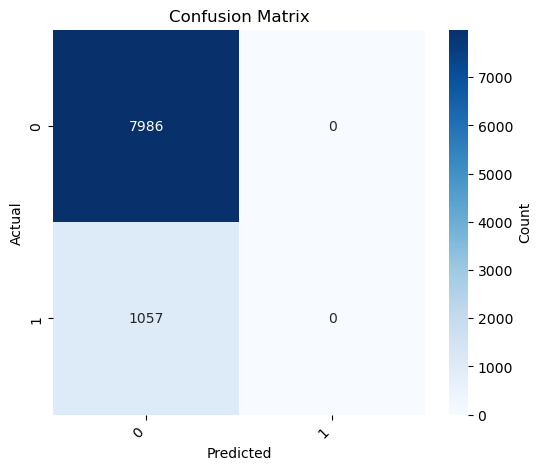

In [124]:
plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    cm_df,
    annot=True, fmt="d",
    cmap="Blues", vmin=0,
    cbar_kws={"label": "Count"}
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.show()

In [125]:
tn, fp, fn, tp = cm.ravel()

In [126]:
(tn + tp)/(tn + fp + fn + tp)

np.float64(0.8831140108371116)

## 'Overfitting' / 'Underfitting'

In [127]:
X_train = sm.add_constant(train[features], has_constant='add')
actual_train = train[target].astype(float)
pred_prob_train = model.predict(X_train)

In [136]:
y_true_train = np.asarray(actual_train, dtype=int)
scores_train = np.asarray(pred_prob_train, dtype=float)

results_train = pd.DataFrame({
    "pred_prob": np.round(np.asarray(scores_train, dtype=float), 4),
    "actual":    np.asarray(y_true_train, dtype=int)
})

pred_class_train = np.where(results_train["pred_prob"].values > opt_thresh, "1", "0")
pred_class_train = pd.Series(pred_class_train)

y_true_train = np.asarray(actual_train, dtype=int)
y_preds_train = np.asarray(pred_class_train, dtype=int)

In [138]:
cm_train = confusion_matrix(y_true_train, y_preds_train, labels=[0, 1])

cm_df_train = pd.DataFrame(cm_train,
                     index=pd.Index([0,1], name="Actual"),
                     columns=pd.Index([0,1], name="Predicted"))
cm_df_train

Predicted,0,1
Actual,,
0,31936,0
1,4232,0


In [139]:
acc_train = accuracy_score(y_true_train, y_preds_train)
acc_test = accuracy_score(y_true, y_preds)

print('Train:',round(acc_train,2),'\n',
      'Test:',round(acc_test,2))

Train: 0.88 
 Test: 0.88
